In [3]:
from google.colab import files
uploaded = files.upload()
from google.colab import files
uploaded = files.upload()

Saving ipl_2024_deliveries.csv to ipl_2024_deliveries.csv
Saving ipl_2024_matches.csv to ipl_2024_matches (2).csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
matches = pd.read_csv('ipl_2024_matches.csv')
deliveries = pd.read_csv('ipl_2024_deliveries.csv')

print(matches.head())
print(deliveries.head())

   match_id  season        date  match_no  \
0    202401    2024  2024-03-22         1   
1    202402    2024  2024-03-23         2   
2    202403    2024  2024-03-23         3   
3    202404    2024  2024-03-24         4   
4    202405    2024  2024-03-24         5   

                                               venue       city team1 team2  \
0           MA Chidambaram Stadium, Chepauk, Chennai    Chennai   RCB   CSK   
1  Maharaja Yadavindra Singh International Cricke...     Mohali    DC  PBKS   
2                              Eden Gardens, Kolkata    Kolkata   KKR   SRH   
3                     Sawai Mansingh Stadium, Jaipur     Jaipur    RR   LSG   
4                   Narendra Modi Stadium, Ahmedabad  Ahmedabad    GT    MI   

  toss_winner toss_decision  ...  innings2_wickets  winning_team  margin  \
0         RCB           bat  ...               4.0           CSK     6.0   
1        PBKS         field  ...               6.0          PBKS     4.0   
2         SRH         fiel

striker
V Kohli            741
RD Gaikwad         583
R Parag            573
TM Head            567
SV Samson          531
B Sai Sudharsan    527
KL Rahul           520
N Pooran           499
SP Narine          488
Abhishek Sharma    484
Name: runs_of_bat, dtype: int64


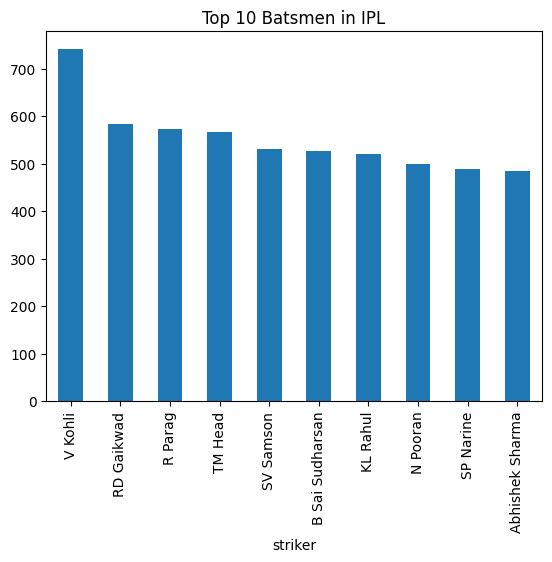

In [15]:
import matplotlib.pyplot as plt

top_batsmen = deliveries.groupby('striker')['runs_of_bat'].sum().sort_values(ascending=False).head(10)

print(top_batsmen)

top_batsmen.plot(kind='bar')
plt.title("Top 10 Batsmen in IPL")
plt.show()

bowler
HV Patel          30
Avesh Khan        22
Mukesh Kumar      22
JJ Bumrah         21
CV Varun          21
Arshdeep Singh    20
MA Starc          20
T Natarajan       20
Harshit Rana      20
AD Russell        19
Name: wicket_type, dtype: int64


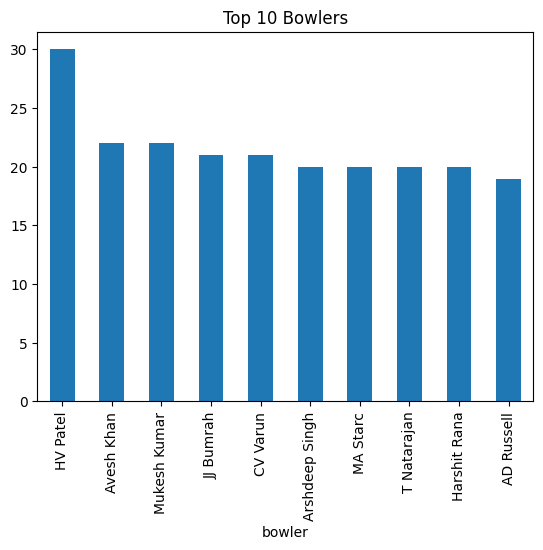

In [17]:
wickets = deliveries[deliveries['wicket_type'].notnull()]
top_bowlers = wickets.groupby('bowler')['wicket_type'].count().sort_values(ascending=False).head(10)

print(top_bowlers)

top_bowlers.plot(kind='bar', title='Top 10 Bowlers')
plt.show()

winning_team
KKR     11
RR       9
SRH      9
CSK      7
DC       7
RCB      7
LSG      7
PBKS     5
GT       5
MI       4
Name: count, dtype: int64


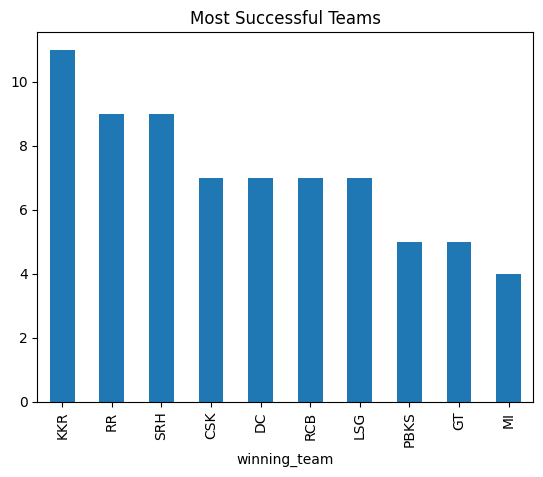

In [19]:
team_wins = matches['winning_team'].value_counts().head(10)

print(team_wins)

team_wins.plot(kind='bar', title='Most Successful Teams')
plt.show()

In [21]:
toss_win_match_win = matches[matches['toss_winner'] == matches['winning_team']]

print("Toss Win -> Match Win %:",
      (len(toss_win_match_win) / len(matches)) * 100)

Toss Win -> Match Win %: 41.891891891891895


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = matches[['team1', 'team2', 'toss_winner', 'winning_team']].dropna()

le = LabelEncoder()

for col in data.columns:
    data[col] = le.fit_transform(data[col])

X = data[['team1', 'team2', 'toss_winner']]
y = data['winning_team']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.6


In [24]:
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Predicted Winner:", prediction)

Predicted Winner: [1]
